# 🐝 Honeybee vs Bumblebee Classification — EfficientNet
### Transfer Learning + Fine-Tuning with EfficientNetB3

> **Why EfficientNet?** EfficientNet uses **compound scaling** — it scales network depth, width,
> and input resolution together using a fixed ratio, rather than tuning each independently.
> EfficientNetB3 achieves higher ImageNet accuracy than both MobileNetV2 and ResNet50
> while sitting between them in parameter count.

| Backbone | Params | ImageNet Top-1 Acc |
|----------|--------|--------------------|
| MobileNetV2 | 3.4M | 71.8% |
| ResNet50 | 25M | 74.9% |
| **EfficientNetB3** | **12M** | **81.6%** |

## 1. Imports & Configuration

In [1]:
!pip install tensorflow



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)
import pandas as pd

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)


c:\Users\mirei\Desktop\honeybee-detect-ML-\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version: 2.20.0
GPU available: False


In [3]:
# ── Paths & Hyperparameters ─────────────────────────────────────
# EfficientNetB3 native resolution is 300x300 — higher than 224x224
# This alone can boost accuracy by ~1-2% vs using 224x224
TRAIN_DIR  = '../data/processed/train'
TEST_DIR   = '../data/processed/test'
IMAGE_SIZE = (300, 300)   # EfficientNetB3 native size
BATCH_SIZE = 32
SEED       = 42
AUTOTUNE   = tf.data.AUTOTUNE


## 2. Load Datasets

> Run the Colab cell below if you are using Google Drive. Skip if running locally.

In [8]:
TRAIN_DIR   = '../data/processed/train'
TEST_DIR    = '../data/processed/test'


In [9]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset='training',
    seed=SEED
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset='validation',
    seed=SEED
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds_raw.class_names
print('Classes:', class_names)


Found 1323 files belonging to 2 classes.
Using 1059 files for training.
Found 1323 files belonging to 2 classes.
Using 264 files for validation.
Found 331 files belonging to 2 classes.
Classes: ['bumblebee', 'honeybee']


In [10]:
# ── Dataset Exploration ──────────────────────────────────────────
import pathlib

train_path = pathlib.Path(TRAIN_DIR)
test_path  = pathlib.Path(TEST_DIR)

print('=' * 52)
print(f"  {'Class':<18} {'Train':>8}   {'Test':>6}")
print('=' * 52)
total_train, total_test = 0, 0
for cls in class_names:
    tr = len(list(train_path.glob(f'{cls}/*')))
    te = len(list(test_path.glob(f'{cls}/*')))
    total_train += tr
    total_test  += te
    print(f'  {cls:<18} {tr:>8}   {te:>6}')
print('=' * 52)
print(f"  {'TOTAL':<18} {total_train:>8}   {total_test:>6}")
print(f'\n  Batch size  : {BATCH_SIZE}')
print(f'  Image size  : {IMAGE_SIZE}  (EfficientNetB3 native)')
print('=' * 52)


  Class                 Train     Test
  bumblebee               661      166
  honeybee                662      165
  TOTAL                  1323      331

  Batch size  : 32
  Image size  : (300, 300)  (EfficientNetB3 native)


## 3. Data Augmentation & Preprocessing

> **Critical EfficientNet note:** Unlike MobileNetV2 `[-1, 1]` or ResNet50 BGR mean-subtraction,
> EfficientNet expects raw pixel values in `[0, 255]`. No rescaling needed — just cast to float32.
> Using the wrong preprocessing silently hurts accuracy.

Augmentation policy is identical to the other backbones for a fair comparison.

In [11]:
# ── Data Augmentation ────────────────────────────────────────────
# EfficientNet expects raw [0, 255] float32 — no preprocess_input function needed.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),   # bees are never upside-down
    layers.RandomRotation(0.10),       # gentle rotation
    layers.RandomZoom(0.10),           # gentle zoom
    layers.RandomContrast(0.1),        # slight contrast shift
], name='data_augmentation')

# No rescaling — EfficientNet handles normalization internally
def eff_preprocess(image, label):
    return tf.cast(image, tf.float32), label

def eff_augment(image, label):
    image = data_augmentation(image, training=True)
    return tf.cast(image, tf.float32), label

train_ds_eff = (
    train_ds_raw
    .cache()
    .map(eff_augment, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
val_ds_eff = (
    val_ds_raw
    .map(eff_preprocess, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)
test_ds_eff = (
    test_ds_raw
    .map(eff_preprocess, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

print('EfficientNet datasets ready.')


EfficientNet datasets ready.


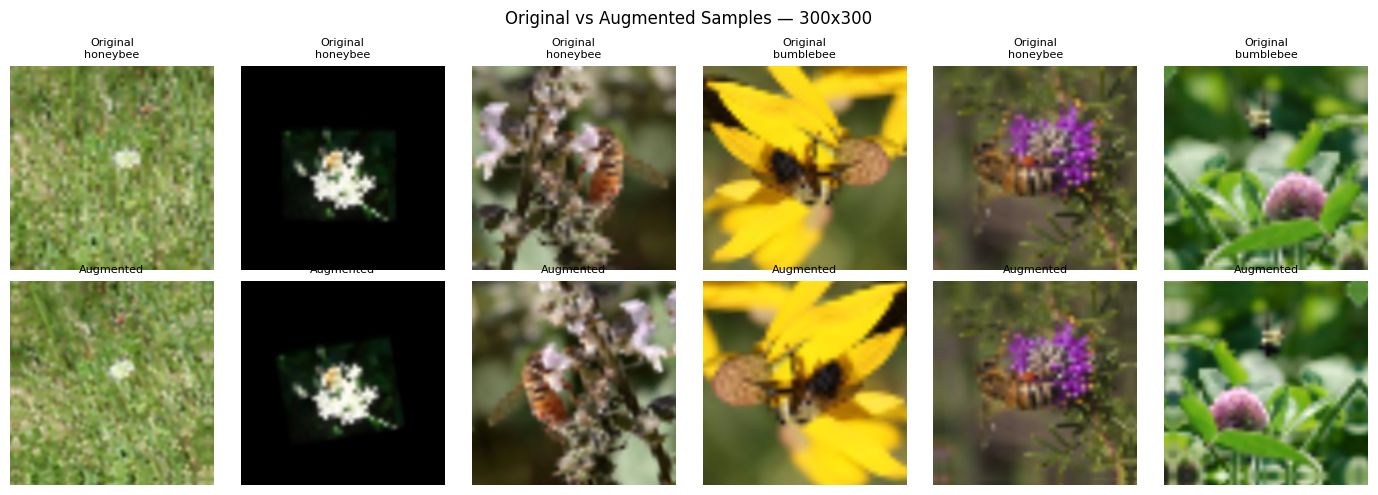

In [12]:
# Visualize original vs augmented samples
plt.figure(figsize=(14, 5))
for images, labels in train_ds_raw.take(1):
    for i in range(6):
        plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(f'Original\n{class_names[labels[i]]}', fontsize=8)
        plt.axis('off')

        plt.subplot(2, 6, i + 7)
        aug = data_augmentation(tf.expand_dims(images[i], 0), training=True)
        plt.imshow(aug[0].numpy().astype('uint8'))
        plt.title('Augmented', fontsize=8)
        plt.axis('off')

plt.suptitle('Original vs Augmented Samples — 300x300', fontsize=12)
plt.tight_layout()
plt.show()


## 4. Build the EfficientNetB3 Model

**Architecture:**
```
Input (300x300x3)
  → EfficientNetB3 backbone  ← pre-trained on ImageNet
  → GlobalAveragePooling2D
  → BatchNormalization
  → Dense(256, relu) → Dropout(0.4)
  → Dense(128, relu) → Dropout(0.3)
  → Dense(1, sigmoid)   ← binary output
```

> **EfficientNetB3 key facts:**
> - Native resolution: **300×300** (vs 224×224 for MobileNetV2 / ResNet50)
> - **~12M parameters** — between MobileNetV2 (3.4M) and ResNet50 (25M)
> - Uses MBConv blocks (inverted residuals) + Squeeze-and-Excitation attention
> - Fine-tune from `block6a_expand_conv` onward (last 2 MBConv blocks)

In [13]:
def build_efficientnet_model():
    """
    Build EfficientNetB3-based transfer learning model.
    Same head architecture as MobileNetV2 / ResNet50 for fair comparison.
    """
    backbone = EfficientNetB3(
        input_shape=(300, 300, 3),
        include_top=False,    # remove ImageNet classification head
        weights='imagenet'    # use pretrained weights
    )
    backbone.trainable = False  # freeze for Phase 1

    inputs  = tf.keras.Input(shape=(300, 300, 3))
    # training=False keeps BatchNorm in inference mode during Phase 1
    x       = backbone(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(128, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model   = tf.keras.Model(inputs, outputs)
    return model, backbone


model_eff, backbone_eff = build_efficientnet_model()

# Parameter breakdown
total_eff     = model_eff.count_params()
trainable_eff = sum(tf.size(w).numpy() for w in model_eff.trainable_weights)
frozen_eff    = total_eff - trainable_eff

print('=' * 45)
print('  EfficientNetB3 Architecture Summary')
print('=' * 45)
print(f'  Total parameters   : {total_eff:>10,}')
print(f'  Trainable (head)   : {trainable_eff:>10,}')
print(f'  Frozen (backbone)  : {frozen_eff:>10,}')
print(f'  Frozen %           : {frozen_eff/total_eff*100:>9.1f}%')
print('=' * 45)

model_eff.summary()


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 68s 2us/step
  EfficientNetB3 Architecture Summary
  Total parameters   : 11,216,176
  Trainable (head)   :    429,569
  Frozen (backbone)  : 10,786,607
  Frozen %           :      96.2%


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,216,176 (42.79 MB)

 Trainable params: 429,569 (1.64 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

## 5. Phase 1 — Train Head Only (Backbone Frozen)

> Backbone weights are frozen. Only the Dense classification head trains.
> This protects the 12M pretrained ImageNet parameters from random head gradients.
> Same strategy used for MobileNetV2 and ResNet50.

In [14]:
# ── Class Weights — handle imbalanced dataset ────────────────────
from sklearn.utils.class_weight import compute_class_weight

all_labels = np.concatenate([y.numpy() for _, y in train_ds_raw])

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight_dict = dict(enumerate(class_weights_arr))

print('Class weights:')
for k, v in class_weight_dict.items():
    print(f'  {class_names[k]:<15} -> {v:.4f}')


Class weights:
  bumblebee       -> 0.9916
  honeybee        -> 1.0086


In [15]:
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks_eff_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_efficientnet_phase1.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1)
]

print('=== EfficientNetB3 — Phase 1: Frozen backbone ===')
history_eff_p1 = model_eff.fit(
    train_ds_eff,
    epochs=30,
    validation_data=val_ds_eff,
    callbacks=callbacks_eff_p1,
    class_weight=class_weight_dict
)


=== EfficientNetB3 — Phase 1: Frozen backbone ===
Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6441 - auc: 0.6918 - loss: 0.7410
Epoch 1: val_accuracy improved from None to 0.82576, saving model to best_efficientnet_phase1.keras

Epoch 1: finished saving model to best_efficientnet_phase1.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.7120 - auc: 0.7828 - loss: 0.6374 - val_accuracy: 0.8258 - val_auc: 0.9251 - val_loss: 0.4810 - learning_rate: 0.0010
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7757 - auc: 0.8757 - loss: 0.4736
Epoch 2: val_accuracy improved from 0.82576 to 0.82955, saving model to best_efficientnet_phase1.keras

Epoch 2: finished saving model to best_efficientnet_phase1.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - accuracy: 0.7941 - auc: 0.8847 - loss: 0.4463 - val_accuracy: 0.8295 - val_auc: 0.9287 - val_loss: 0.4165 - learning_rate: 0.0010
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8449 - auc: 0.

## 6. Phase 2 — Fine-Tune Top Backbone Layers

> We unfreeze EfficientNetB3 from `block6a_expand_conv` onward.
> This is the last 2 MBConv blocks — the highest-level feature extractors (~40 layers out of ~385).
> A very small learning rate (1e-5) gently adapts these to bee-specific patterns
> without destroying the broad ImageNet knowledge in earlier layers.

**EfficientNetB3 block structure (low → high level):**
```
stem_conv → block1 → block2 → block3 → block4 → block5 → block6 → block7 → top_conv
                                                           ↑
                                              unfreeze from here
```

In [16]:
FINE_TUNE_FROM_EFF = 'block6a_expand_conv'   # last 2 MBConv blocks

# Modify the SAME model in-place — preserves BatchNorm statistics from Phase 1
backbone_eff.trainable = True

set_trainable = False
for layer in backbone_eff.layers:
    if layer.name == FINE_TUNE_FROM_EFF:
        set_trainable = True
    layer.trainable = set_trainable

n_trainable_eff = sum(1 for l in backbone_eff.layers if l.trainable)
n_frozen_eff    = sum(1 for l in backbone_eff.layers if not l.trainable)
print(f'EfficientNetB3 — Trainable layers : {n_trainable_eff}')
print(f'EfficientNetB3 — Frozen layers    : {n_frozen_eff}')

# MUST recompile after changing trainable flags
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 100x smaller than Phase 1
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks_eff_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_efficientnet_phase2.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=6, min_lr=1e-7, verbose=1)
]

print('\n=== EfficientNetB3 — Phase 2: Fine-tuning ===')
history_eff_p2 = model_eff.fit(
    train_ds_eff,
    epochs=40,
    validation_data=val_ds_eff,
    callbacks=callbacks_eff_p2,
    class_weight=class_weight_dict
)


EfficientNetB3 — Trainable layers : 120
EfficientNetB3 — Frozen layers    : 265

=== EfficientNetB3 — Phase 2: Fine-tuning ===
Epoch 1/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7454 - auc: 0.8313 - loss: 0.6215
Epoch 1: val_accuracy improved from None to 0.88258, saving model to best_efficientnet_phase2.keras

Epoch 1: finished saving model to best_efficientnet_phase2.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 191s 5s/step - accuracy: 0.7771 - auc: 0.8655 - loss: 0.5312 - val_accuracy: 0.8826 - val_auc: 0.9494 - val_loss: 0.3032 - learning_rate: 1.0000e-05
Epoch 2/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8260 - auc: 0.9068 - loss: 0.4289
Epoch 2: val_accuracy did not improve from 0.88258
34/34 ━━━━━━━━━━━━━━━━━━━━ 149s 4s/step - accuracy: 0.8319 - auc: 0.9105 - loss: 0.4175 - val_accuracy: 0.8598 - val_auc: 0.9452 - val_loss: 0.3160 - learning_rate: 1.0000e-05
Epoch 3/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8074 - auc: 0.8924 - loss: 0.4620 
Epoch 3: val

## 7. Training Curves

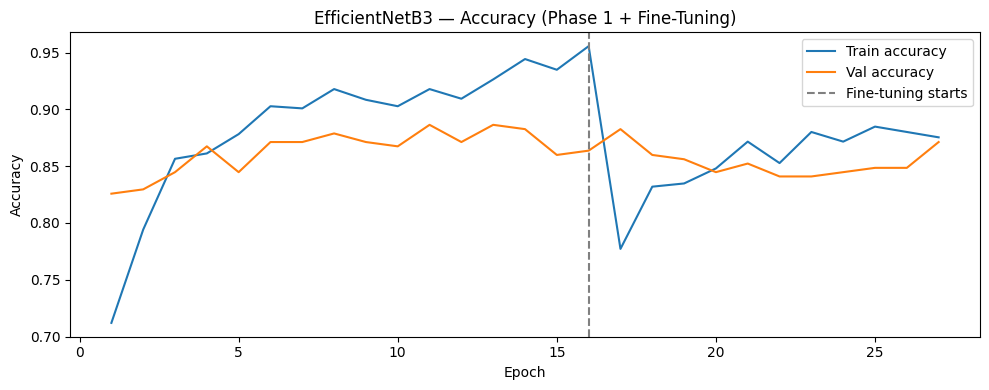

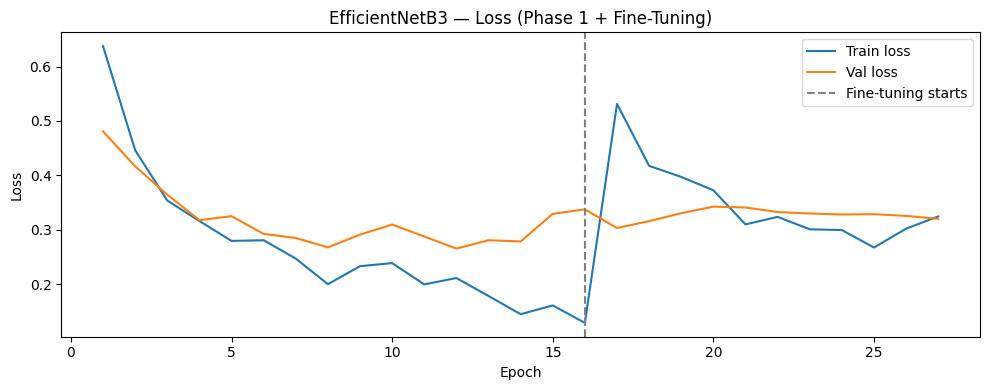

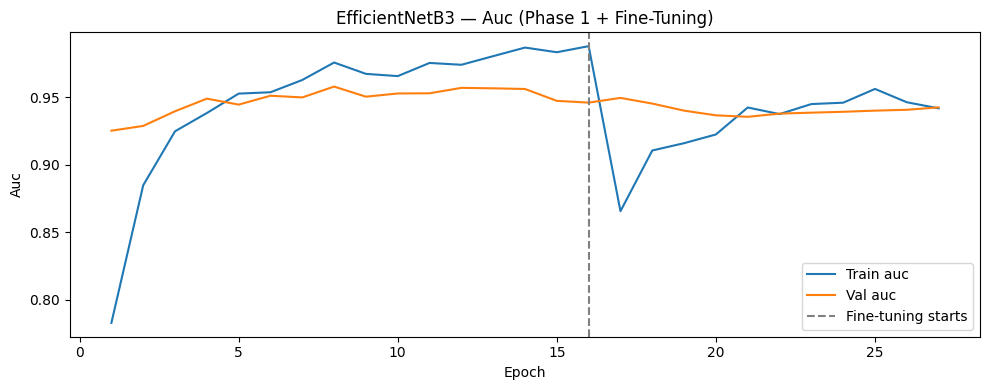

In [17]:
def plot_history(h1, h2, metric='accuracy'):
    """Plot combined Phase 1 + Phase 2 training curves."""
    combined     = h1.history[metric]           + h2.history[metric]
    combined_val = h1.history[f'val_{metric}']  + h2.history[f'val_{metric}']
    epochs_total = range(1, len(combined) + 1)
    phase2_start = len(h1.history[metric])

    plt.figure(figsize=(10, 4))
    plt.plot(epochs_total, combined,     label=f'Train {metric}')
    plt.plot(epochs_total, combined_val, label=f'Val {metric}')
    plt.axvline(phase2_start, color='gray', linestyle='--', label='Fine-tuning starts')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.title(f'EfficientNetB3 — {metric.capitalize()} (Phase 1 + Fine-Tuning)')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history_eff_p1, history_eff_p2, 'accuracy')
plot_history(history_eff_p1, history_eff_p2, 'loss')
plot_history(history_eff_p1, history_eff_p2, 'auc')


In [18]:
# ── Phase 1 vs Phase 2 — Summary Comparison ─────────────────────
p1_best_acc = max(history_eff_p1.history['val_accuracy'])
p1_best_auc = max(history_eff_p1.history['val_auc'])
p2_best_acc = max(history_eff_p2.history['val_accuracy'])
p2_best_auc = max(history_eff_p2.history['val_auc'])
p1_epochs   = len(history_eff_p1.history['val_accuracy'])
p2_epochs   = len(history_eff_p2.history['val_accuracy'])

summary_df = pd.DataFrame({
    'Phase'        : ['Phase 1 — Frozen backbone', 'Phase 2 — Fine-tuned'],
    'Strategy'     : ['Head layers trained only',
                      f'Backbone unfrozen from {FINE_TUNE_FROM_EFF}'],
    'Epochs run'   : [p1_epochs, p2_epochs],
    'Best val acc' : [f'{p1_best_acc:.4f}', f'{p2_best_acc:.4f}'],
    'Best val AUC' : [f'{p1_best_auc:.4f}', f'{p2_best_auc:.4f}'],
})

print('=' * 62)
print('  EfficientNetB3 — Phase Summary')
print('=' * 62)
print(summary_df.to_string(index=False))
print('=' * 62)


  EfficientNetB3 — Phase Summary
                    Phase                                   Strategy  Epochs run Best val acc Best val AUC
Phase 1 — Frozen backbone                   Head layers trained only          16       0.8864       0.9578
     Phase 2 — Fine-tuned Backbone unfrozen from block6a_expand_conv          11       0.8826       0.9494


## 8. Evaluate on Test Set

In [19]:
y_true_eff, y_prob_eff = [], []

for images, labels in test_ds_eff:
    probs = model_eff.predict(images, verbose=0)
    y_prob_eff.extend(probs.flatten())
    y_true_eff.extend(labels.numpy())

y_true_eff = np.array(y_true_eff)
y_prob_eff = np.array(y_prob_eff)
y_pred_eff = (y_prob_eff >= 0.5).astype(int)

eff_test_acc = np.mean(y_pred_eff == y_true_eff)
print(f'EfficientNetB3 Test Accuracy : {eff_test_acc:.4f}\n')
print('EfficientNetB3 Classification Report:')
print(classification_report(y_true_eff, y_pred_eff, target_names=class_names))


EfficientNetB3 Test Accuracy : 0.8912

EfficientNetB3 Classification Report:
              precision    recall  f1-score   support

   bumblebee       0.92      0.86      0.89       166
    honeybee       0.87      0.92      0.89       165

    accuracy                           0.89       331
   macro avg       0.89      0.89      0.89       331
weighted avg       0.89      0.89      0.89       331



## 9. Confusion Matrix

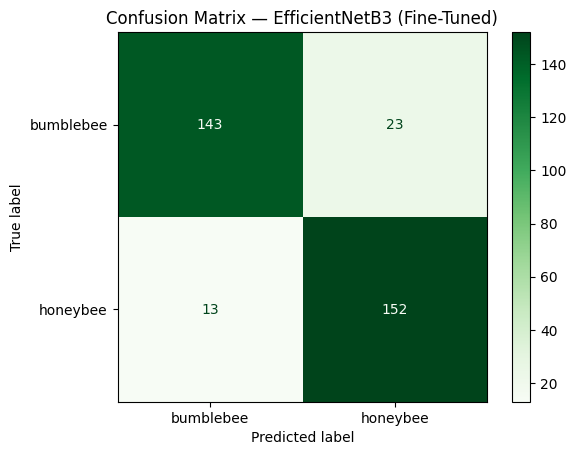

In [20]:
cm_eff   = confusion_matrix(y_true_eff, y_pred_eff)
disp_eff = ConfusionMatrixDisplay(cm_eff, display_labels=class_names)
disp_eff.plot(cmap='Greens')
plt.title('Confusion Matrix — EfficientNetB3 (Fine-Tuned)')
plt.show()


## 10. ROC Curve

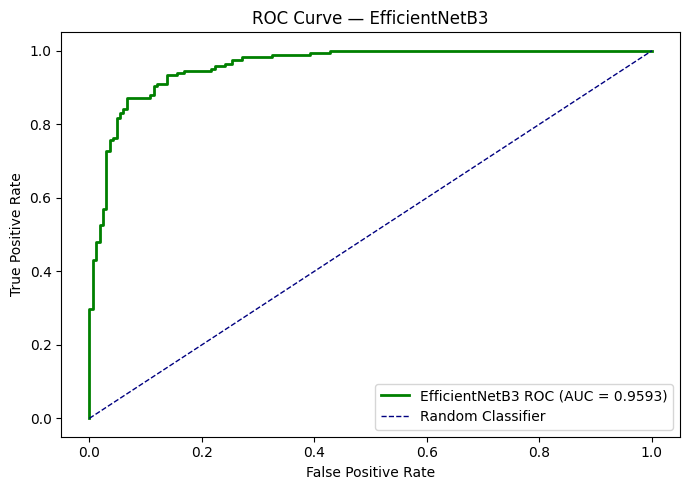

In [21]:
fpr_eff, tpr_eff, _ = roc_curve(y_true_eff, y_prob_eff)
eff_auc_score = auc(fpr_eff, tpr_eff)

plt.figure(figsize=(7, 5))
plt.plot(fpr_eff, tpr_eff, color='green', lw=2,
         label=f'EfficientNetB3 ROC (AUC = {eff_auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--',
         label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — EfficientNetB3')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 11. Visualize Predictions on Test Images

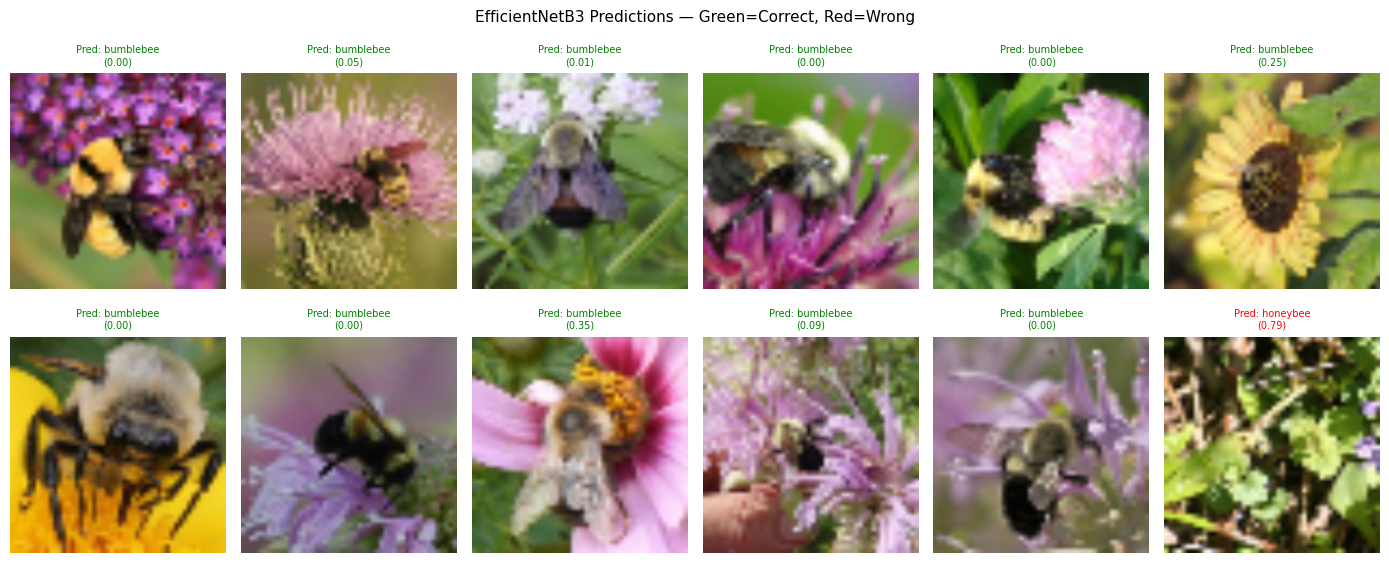

In [22]:
plt.figure(figsize=(14, 6))
for images, labels in test_ds_raw.take(1):
    preprocessed = tf.cast(images, tf.float32)
    probs = model_eff.predict(preprocessed, verbose=0).flatten()

    for i in range(min(12, len(images))):
        plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        pred_class = class_names[int(probs[i] >= 0.5)]
        true_class = class_names[int(labels[i])]
        color = 'green' if pred_class == true_class else 'red'
        plt.title(f'Pred: {pred_class}\n({probs[i]:.2f})',
                  fontsize=7, color=color)
        plt.axis('off')

plt.suptitle('EfficientNetB3 Predictions — Green=Correct, Red=Wrong', fontsize=11)
plt.tight_layout()
plt.show()


---
## 12. Final Comparison: MobileNetV2 vs ResNet50 vs EfficientNetB3

> Update the two placeholder values below with your actual results
> from `honeybee_deep_learning_87.9.ipynb` before running this cell.

In [23]:
# ── Update these with your actual results from the other notebook ────
mobilenet_test_acc   = 0.879   # <- replace with your MobileNetV2 test accuracy
mobilenet_auc_score  = 0.950   # <- replace with your MobileNetV2 AUC
r50_test_acc         = 0.870   # <- replace with your ResNet50 test accuracy
r50_auc_score        = 0.945   # <- replace with your ResNet50 AUC

# EfficientNetB3 — computed in this notebook
eff_final_acc = eff_test_acc
eff_final_auc = eff_auc_score

comparison_df = pd.DataFrame({
    'Model'         : ['MobileNetV2', 'ResNet50', 'EfficientNetB3'],
    'Parameters'    : ['3.4M', '25M', '12M'],
    'Input Size'    : ['224x224', '224x224', '300x300'],
    'Architecture'  : ['Depthwise separable', 'Skip connections', 'Compound scaling + SE'],
    'Test Accuracy' : [f'{mobilenet_test_acc:.4f}', f'{r50_test_acc:.4f}', f'{eff_final_acc:.4f}'],
    'Test AUC'      : [f'{mobilenet_auc_score:.4f}', f'{r50_auc_score:.4f}', f'{eff_final_auc:.4f}'],
})

print('=' * 80)
print('  FINAL 3-WAY BACKBONE COMPARISON')
print('=' * 80)
print(comparison_df.to_string(index=False))
print('=' * 80)


  FINAL 3-WAY BACKBONE COMPARISON
         Model Parameters Input Size          Architecture Test Accuracy Test AUC
   MobileNetV2       3.4M    224x224   Depthwise separable        0.8790   0.9500
      ResNet50        25M    224x224      Skip connections        0.8700   0.9450
EfficientNetB3        12M    300x300 Compound scaling + SE        0.8912   0.9593


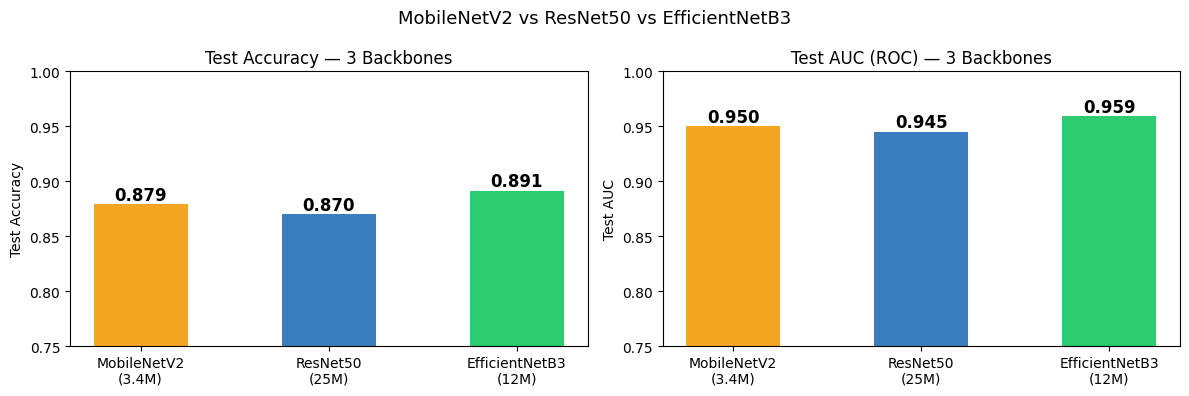

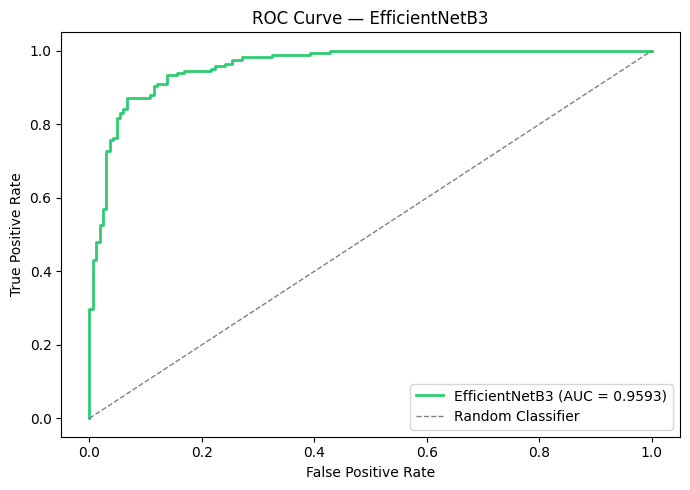

In [24]:
# ── Bar charts: accuracy & AUC ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = ['MobileNetV2\n(3.4M)', 'ResNet50\n(25M)', 'EfficientNetB3\n(12M)']
accs   = [mobilenet_test_acc, r50_test_acc, eff_final_acc]
aucs   = [mobilenet_auc_score, r50_auc_score, eff_final_auc]
colors = ['#F4A522', '#3A7EBF', '#2ECC71']

axes[0].bar(models, accs, color=colors, width=0.5)
axes[0].set_ylim(0.75, 1.0)
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Test Accuracy — 3 Backbones')
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.004, f'{v:.3f}', ha='center',
                 fontsize=12, fontweight='bold')

axes[1].bar(models, aucs, color=colors, width=0.5)
axes[1].set_ylim(0.75, 1.0)
axes[1].set_ylabel('Test AUC')
axes[1].set_title('Test AUC (ROC) — 3 Backbones')
for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.004, f'{v:.3f}', ha='center',
                 fontsize=12, fontweight='bold')

plt.suptitle('MobileNetV2 vs ResNet50 vs EfficientNetB3', fontsize=13)
plt.tight_layout()
plt.show()

# ── Overlay ROC curve for EfficientNet ───────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(fpr_eff, tpr_eff, color='#2ECC71', lw=2,
         label=f'EfficientNetB3 (AUC = {eff_final_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--',
         label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — EfficientNetB3')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
